In [ ]:
import json
from collections import Counter

base = r"C:\Users\bgano\Desktop\DataDriven\pasketti\data\drivendata"

with open(f"{base}\\train_phon_transcripts.jsonl") as f:
    utterances = [json.loads(l) for l in f]

# === Basic stats ===
print(f"Total utterances: {len(utterances)}")
print(f"Total hours: {sum(u['audio_duration_sec'] for u in utterances)/3600:.1f}h")

# === Age distribution ===
ages = Counter(u["age_bucket"] for u in utterances)
print(f"\nAge distribution:")
for age, count in sorted(ages.items()):
    pct = count/len(utterances)*100
    print(f"  {age:8s}: {count:5d} ({pct:.1f}%)")

# === IPA vocabulary ===
all_chars = Counter(c for u in utterances for c in u["phonetic_text"])
print(f"\nIPA vocab size: {len(all_chars)} unique characters")
print(f"Most common phones: {all_chars.most_common(10)}")
print(f"Rarest phones: {all_chars.most_common()[-10:]}")

# === Duration stats ===
durations = [u["audio_duration_sec"] for u in utterances]
print(f"\nDuration stats:")
print(f"  Min:    {min(durations):.1f}s")
print(f"  Max:    {max(durations):.1f}s")
print(f"  Mean:   {sum(durations)/len(durations):.1f}s")

# === Unique speakers ===
speakers = Counter(u["child_id"] for u in utterances)
print(f"\nUnique children: {len(speakers)}")
print(f"Avg utterances per child: {len(utterances)/len(speakers):.1f}")

Total utterances: 12043
Total hours: 6.4h

Age distribution:
  3-4     : 10112 (84.0%)
  5-7     :  1893 (15.7%)
  8-11    :    38 (0.3%)

IPA vocab size: 50 unique characters
Most common phones: [(' ', 24947), ('i', 9101), ('ɪ', 7292), ('ɑ', 6983), ('n', 6763), ('ə', 5975), ('t', 5830), ('d', 5392), ('s', 4681), ('k', 4641)]
Rarest phones: [('ʤ', 450), ('ɐ', 103), ('ʒ', 27), ('ɬ', 27), ('ç', 19), ('c', 14), ('ʝ', 13), ('ʁ', 11), ('x', 9), ('ɟ', 5)]

Duration stats:
  Min:    0.1s
  Max:    21.4s
  Mean:   1.9s

Unique children: 107
Avg utterances per child: 112.6


In [ ]:
import os
from pathlib import Path

base = Path(r"C:\Users\bgano\Desktop\DataDriven\pasketti\data\drivendata")
audio_dir = base / "audio"

# Count files
flac_files = list(audio_dir.rglob("*.flac"))
print(f"Total .flac files found: {len(flac_files):,}")

print("Sample audio_path from manifest:", utterances[0]["audio_path"])
print("Does file exist:", (base / utterances[0]["audio_path"]).exists())

# Sample a few paths
print("\nSample paths:")
for f in flac_files[:3]:
    print(f"  {f}")
    print(f"  Size: {f.stat().st_size / 1024:.1f} KB")

Total .flac files found: 12,043
Sample audio_path from manifest: audio/U_0004fcba47fc2b22.flac
Does file exist: False

Sample paths:
  C:\Users\bgano\Desktop\DataDriven\pasketti\data\drivendata\audio\audio\U_0004fcba47fc2b22.flac
  Size: 118.5 KB
  C:\Users\bgano\Desktop\DataDriven\pasketti\data\drivendata\audio\audio\U_000727b46808376d.flac
  Size: 38.8 KB
  C:\Users\bgano\Desktop\DataDriven\pasketti\data\drivendata\audio\audio\U_0012a1c1c3646a51.flac
  Size: 56.4 KB


DATASET OVERVIEW
Total utterances:  12,043
Total hours:       6.4h

AGE DISTRIBUTION
------------------------------
  3-4     : 10,112 (84.0%) █████████████████████████████████
  5-7     : 1,893 (15.7%) ██████
  8-11    :    38 (0.3%) 

IPA VOCABULARY
------------------------------
  Vocab size:      50 unique phones
  Most common:     [(' ', 24947), ('i', 9101), ('ɪ', 7292), ('ɑ', 6983), ('n', 6763)]
  Rarest:          [('c', 14), ('ʝ', 13), ('ʁ', 11), ('x', 9), ('ɟ', 5)]

DURATION STATS
------------------------------
  Min:    0.15s
  Max:    21.38s
  Mean:   1.93s
  Median: 1.42s

SPEAKER STATS
------------------------------
  Unique children:          107
  Avg utterances/child:     112.6
  Max utterances (1 child): 546
  Min utterances (1 child): 1

TRANSCRIPT LENGTH (characters)
------------------------------
  Min:    1
  Max:    152
  Mean:   12.0


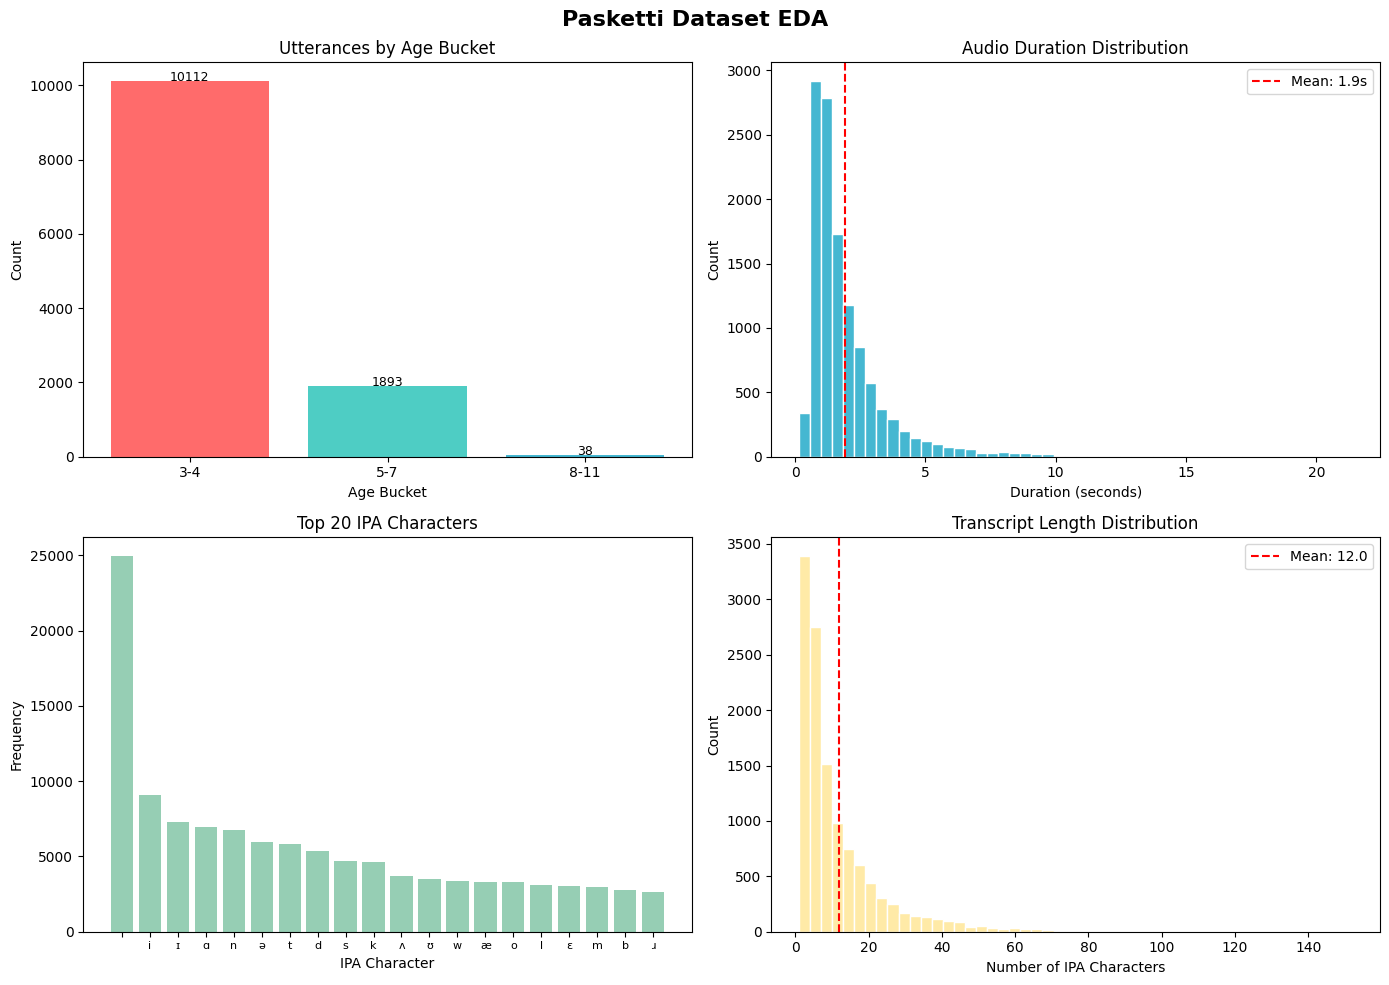


Plot saved to notebooks/eda_overview.png


In [ ]:
import json
import numpy as np
import librosa
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

base = Path(r"C:\Users\bgano\Desktop\DataDriven\pasketti\data\drivendata")

# Load manifest
with open(base / "train_phon_transcripts.jsonl") as f:
    utterances = [json.loads(l) for l in f]

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total utterances:  {len(utterances):,}")
print(f"Total hours:       {sum(u['audio_duration_sec'] for u in utterances)/3600:.1f}h")

# Age distribution
print("\nAGE DISTRIBUTION")
print("-" * 30)
ages = Counter(u["age_bucket"] for u in utterances)
for age, count in sorted(ages.items()):
    bar = "█" * int(count / len(utterances) * 40)
    print(f"  {age:8s}: {count:5,} ({count/len(utterances)*100:.1f}%) {bar}")

# IPA vocabulary
print("\nIPA VOCABULARY")
print("-" * 30)
all_chars = Counter(c for u in utterances for c in u["phonetic_text"])
print(f"  Vocab size:      {len(all_chars)} unique phones")
print(f"  Most common:     {all_chars.most_common(5)}")
print(f"  Rarest:          {all_chars.most_common()[-5:]}")

# Duration stats
durations = [u["audio_duration_sec"] for u in utterances]
print("\nDURATION STATS")
print("-" * 30)
print(f"  Min:    {min(durations):.2f}s")
print(f"  Max:    {max(durations):.2f}s")
print(f"  Mean:   {np.mean(durations):.2f}s")
print(f"  Median: {np.median(durations):.2f}s")

# Speakers
speakers = Counter(u["child_id"] for u in utterances)
print("\nSPEAKER STATS")
print("-" * 30)
print(f"  Unique children:          {len(speakers):,}")
print(f"  Avg utterances/child:     {len(utterances)/len(speakers):.1f}")
print(f"  Max utterances (1 child): {max(speakers.values()):,}")
print(f"  Min utterances (1 child): {min(speakers.values()):,}")

# Transcript length stats
lengths = [len(u["phonetic_text"]) for u in utterances]
print("\nTRANSCRIPT LENGTH (characters)")
print("-" * 30)
print(f"  Min:    {min(lengths)}")
print(f"  Max:    {max(lengths)}")
print(f"  Mean:   {np.mean(lengths):.1f}")

# Visual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Pasketti Dataset EDA", fontsize=16, fontweight="bold")

# Plot 1: Age distribution
ax1 = axes[0, 0]
age_labels, age_counts = zip(*sorted(ages.items()))
bars = ax1.bar(age_labels, age_counts, color=["#FF6B6B","#4ECDC4","#45B7D1","#96CEB4","#FFEAA7"])
ax1.set_title("Utterances by Age Bucket")
ax1.set_xlabel("Age Bucket")
ax1.set_ylabel("Count")
for bar, count in zip(bars, age_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha="center", fontsize=9)

# Plot 2: Duration distribution
ax2 = axes[0, 1]
ax2.hist(durations, bins=50, color="#45B7D1", edgecolor="white")
ax2.set_title("Audio Duration Distribution")
ax2.set_xlabel("Duration (seconds)")
ax2.set_ylabel("Count")
ax2.axvline(np.mean(durations), color="red", linestyle="--",
            label=f"Mean: {np.mean(durations):.1f}s")
ax2.legend()

# Plot 3: IPA character frequency
ax3 = axes[1, 0]
top_chars = all_chars.most_common(20)
chars, counts = zip(*top_chars)
ax3.bar(range(len(chars)), counts, color="#96CEB4")
ax3.set_xticks(range(len(chars)))
ax3.set_xticklabels(chars, fontsize=8)
ax3.set_title("Top 20 IPA Characters")
ax3.set_xlabel("IPA Character")
ax3.set_ylabel("Frequency")

# Plot 4: Transcript length distribution
ax4 = axes[1, 1]
ax4.hist(lengths, bins=50, color="#FFEAA7", edgecolor="white")
ax4.set_title("Transcript Length Distribution")
ax4.set_xlabel("Number of IPA Characters")
ax4.set_ylabel("Count")
ax4.axvline(np.mean(lengths), color="red", linestyle="--",
            label=f"Mean: {np.mean(lengths):.1f}")
ax4.legend()

plt.tight_layout()
# plt.savefig("notebooks/eda_overview.png", dpi=150, bbox_inches="tight")

# # Replace this:
# plt.savefig("notebooks/eda_overview.png", dpi=150, bbox_inches="tight")

# With this:
plt.savefig(r"C:\Users\bgano\Desktop\DataDriven\pasketti\notebooks\eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved to notebooks/eda_overview.png")

In [ ]:
import json
import numpy as np
from collections import Counter
from pathlib import Path

base = Path(r"C:\Users\bgano\Desktop\DataDriven\pasketti\data\drivendata")

with open(base / "train_phon_transcripts.jsonl") as f:
    utterances = [json.loads(l) for l in f]

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total utterances:  {len(utterances):,}")
print(f"Total hours:       {sum(u['audio_duration_sec'] for u in utterances)/3600:.1f}h")

# Age distribution
print("\nAGE DISTRIBUTION")
print("-" * 30)
ages = Counter(u["age_bucket"] for u in utterances)
for age, count in sorted(ages.items()):
    bar = "█" * int(count / len(utterances) * 40)
    print(f"  {age:8s}: {count:5,} ({count/len(utterances)*100:.1f}%) {bar}")

# IPA vocabulary
print("\nIPA VOCABULARY")
print("-" * 30)
all_chars = Counter(c for u in utterances for c in u["phonetic_text"])
print(f"  Vocab size:        {len(all_chars)} unique phones")
print(f"  Most common:       {all_chars.most_common(5)}")
print(f"  Rarest:            {all_chars.most_common()[-5:]}")
print(f"  Full vocab:        {''.join(sorted(all_chars.keys()))}")

# Duration stats
durations = [u["audio_duration_sec"] for u in utterances]
print("\nDURATION STATS")
print("-" * 30)
print(f"  Min:      {min(durations):.2f}s")
print(f"  Max:      {max(durations):.2f}s")
print(f"  Mean:     {np.mean(durations):.2f}s")
print(f"  Median:   {np.median(durations):.2f}s")
print(f"  <0.3s:    {sum(1 for d in durations if d < 0.3):,} utterances")
print(f"  >10s:     {sum(1 for d in durations if d > 10):,} utterances")

# Speakers
speakers = Counter(u["child_id"] for u in utterances)
print("\nSPEAKER STATS")
print("-" * 30)
print(f"  Unique children:           {len(speakers):,}")
print(f"  Avg utterances/child:      {len(utterances)/len(speakers):.1f}")
print(f"  Max utterances (1 child):  {max(speakers.values()):,}")
print(f"  Min utterances (1 child):  {min(speakers.values()):,}")
print(f"  Median per child:          {np.median(list(speakers.values())):.0f}")

# Speakers per age bucket
print("\nSPEAKERS PER AGE BUCKET")
print("-" * 30)
age_speakers = {}
for u in utterances:
    age = u["age_bucket"]
    child = u["child_id"]
    if age not in age_speakers:
        age_speakers[age] = set()
    age_speakers[age].add(child)
for age, children in sorted(age_speakers.items()):
    print(f"  {age:8s}: {len(children):3d} unique children")

# Transcript length
lengths = [len(u["phonetic_text"]) for u in utterances]
print("\nTRANSCRIPT LENGTH")
print("-" * 30)
print(f"  Min:      {min(lengths)}")
print(f"  Max:      {max(lengths)}")
print(f"  Mean:     {np.mean(lengths):.1f}")
print(f"  Median:   {np.median(lengths):.0f}")

# Problematic utterances
print("\nDATA QUALITY FLAGS")
print("-" * 30)
very_short = [u for u in utterances if u["audio_duration_sec"] < 0.3]
very_long   = [u for u in utterances if u["audio_duration_sec"] > 15]
empty       = [u for u in utterances if len(u["phonetic_text"].strip()) == 0]
print(f"  Very short (<0.3s):   {len(very_short):,}")
print(f"  Very long  (>15s):    {len(very_long):,}")
print(f"  Empty transcripts:    {len(empty):,}")
print(f"  Usable after filter:  {len(utterances)-len(very_short)-len(empty):,}")

print("\n✅ EDA Complete!")

DATASET OVERVIEW
Total utterances:  12,043
Total hours:       6.4h

AGE DISTRIBUTION
------------------------------
  3-4     : 10,112 (84.0%) █████████████████████████████████
  5-7     : 1,893 (15.7%) ██████
  8-11    :    38 (0.3%) 

IPA VOCABULARY
------------------------------
  Vocab size:        50 unique phones
  Most common:       [(' ', 24947), ('i', 9101), ('ɪ', 7292), ('ɑ', 6983), ('n', 6763)]
  Rarest:            [('c', 14), ('ʝ', 13), ('ʁ', 11), ('x', 9), ('ɟ', 5)]
  Full vocab:         bcdefghijklmnopstuvwxzæçðŋɐɑɔəɚɛɟɪɫɬɹɾʁʃʊʌʒʔʝʤʧːθ

DURATION STATS
------------------------------
  Min:      0.15s
  Max:      21.38s
  Mean:     1.93s
  Median:   1.42s
  <0.3s:    33 utterances
  >10s:     33 utterances

SPEAKER STATS
------------------------------
  Unique children:           107
  Avg utterances/child:      112.6
  Max utterances (1 child):  546
  Min utterances (1 child):  1
  Median per child:          43

SPEAKERS PER AGE BUCKET
------------------------------
  3-4 

In [ ]:
import json
from pathlib import Path

base = Path(r"C:\Users\bgano\Desktop\DataDriven\pasketti\data\drivendata")

with open(base / "train_phon_transcripts.jsonl") as f:
    utterances = [json.loads(l) for l in f]

from collections import Counter
all_chars = Counter(c for u in utterances for c in u["phonetic_text"])

# Build vocab
vocab = {char: idx for idx, char in enumerate(sorted(all_chars.keys()))}
vocab["[UNK]"] = len(vocab)
vocab["[PAD]"] = len(vocab)  # CTC blank

print(f"Vocab size: {len(vocab)}")
print(f"Vocab: {vocab}")

# Save it
vocab_path = Path(r"C:\Users\bgano\Desktop\DataDriven\pasketti\data\vocab.json")
with open(vocab_path, "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False, indent=2)

print(f"\nVocab saved to {vocab_path}")

Vocab size: 52
Vocab: {' ': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 's': 16, 't': 17, 'u': 18, 'v': 19, 'w': 20, 'x': 21, 'z': 22, 'æ': 23, 'ç': 24, 'ð': 25, 'ŋ': 26, 'ɐ': 27, 'ɑ': 28, 'ɔ': 29, 'ə': 30, 'ɚ': 31, 'ɛ': 32, 'ɟ': 33, 'ɪ': 34, 'ɫ': 35, 'ɬ': 36, 'ɹ': 37, 'ɾ': 38, 'ʁ': 39, 'ʃ': 40, 'ʊ': 41, 'ʌ': 42, 'ʒ': 43, 'ʔ': 44, 'ʝ': 45, 'ʤ': 46, 'ʧ': 47, 'ː': 48, 'θ': 49, '[UNK]': 50, '[PAD]': 51}

Vocab saved to C:\Users\bgano\Desktop\DataDriven\pasketti\data\vocab.json


In [3]:
# In notebook - confirm labels decode correctly
import json
from pathlib import Path

with open(r"C:\Users\bgano\Desktop\DataDriven\pasketti\data\ipa_processor\vocab.json", encoding="utf-8") as f:
    vocab = json.load(f)

idx2char = {v: k for k, v in vocab.items()}
labels = [44, 30, 0, 44, 23, 15, 35]
decoded = "".join(idx2char[i] for i in labels)
print(f"Decoded: '{decoded}'")
# Expected: 'ʔə ʔæpɫ' ✅

Decoded: 'ʔə ʔæpɫ'


: 